In [1]:
from fleet_replacement.episode import EpisodeRecord, EpisodeRecorder
from fleet_replacement.envs.fleet_replacement import FleetReplacementEnv
from fleet_replacement.policies import LookaheadAgent
from fleet_replacement.config import load_env_config

config = load_env_config("../configs/env.yaml")
env = EpisodeRecorder(FleetReplacementEnv(config=config))
agent = LookaheadAgent(config)

obs, _ = env.reset(seed=100)
while True:
    obs, reward, terminated, truncated, info = env.step(agent.select_action(obs))
    if terminated or truncated:
        break

record = env.episode_record
df = record.to_dataframe()  # pandas DataFrame, indexed by year
record.save("../results/ep42.pkl")  # persist

# For visualisation:
record.years  # (35,)
record.n_electric  # (35,)
record.actions  # (35, 10)  — heatmap of decisions per slot
record.reward_component("revenue")  # (35,)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\comm

array([31200000.        , 31200000.        , 31200000.        ,
       31200000.        , 31200000.        , 30520034.71959602,
       30090282.66082282, 29863421.57782708, 29758098.13951293,
       29699453.06289485, 29120024.40316787, 29324020.88115258,
       29450073.52325061, 29526602.27661422, 29572567.86168855,
       29599998.3334171 , 29616304.65749013, 29625975.86631031,
       29631704.00079372, 29635093.96234989])

In [2]:
agent.forecast_params

ForecastParams(diesel_price_growth=0.0, electricity_price_growth=0.0, purchase_price_growth_DT=0.0, BET_price_gap_closure_rate=0.0, BET_productivity_growth=0.0)

In [3]:
df.head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2026,0,8,3.5,18.000000,3.000000,1800000.0,3200000.00,0.710332,11580484.0,31200000.0,1.152320e+07,0.0,6400000.0,472320.0,2160000.0,936000.0,2632320.0,1.792320e+07,11580484.0
2027,0,8,3.5,18.466660,3.092706,1800000.0,2974397.25,0.716992,11573888.0,31200000.0,1.152979e+07,0.0,6400000.0,472320.0,2160000.0,936000.0,2632320.0,1.792979e+07,11573888.0
2028,0,8,3.5,18.477232,3.225496,1800000.0,2809663.50,0.727455,11176334.0,31200000.0,1.192735e+07,0.0,6400000.0,472320.0,2160000.0,936000.0,2632320.0,1.832735e+07,11176334.0
2029,0,8,3.5,19.114338,3.320413,1800000.0,2718165.50,0.743167,10379638.0,31200000.0,1.272404e+07,0.0,6400000.0,472320.0,2160000.0,936000.0,2632320.0,1.912404e+07,10379638.0
2030,0,8,3.5,20.391092,3.237591,1800000.0,2539253.50,0.765235,9661764.0,31200000.0,1.344192e+07,0.0,6400000.0,472320.0,2160000.0,936000.0,2632320.0,1.984192e+07,9661764.0


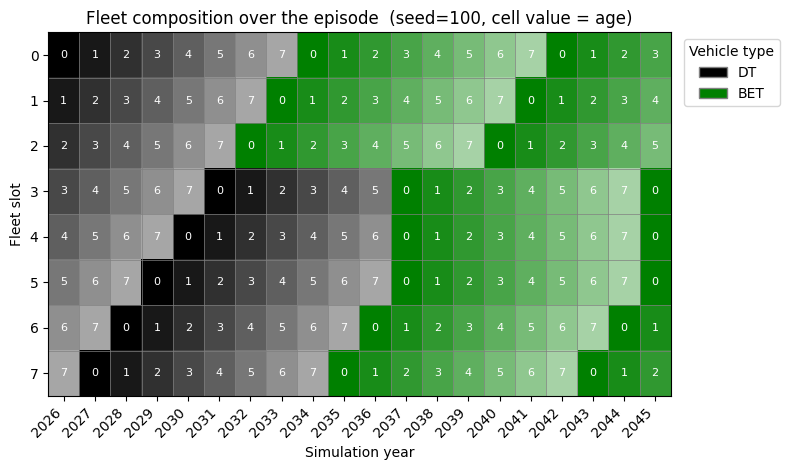

In [4]:
from plot_helpers import plot_episode_fleet_composition

plot_episode_fleet_composition(record)

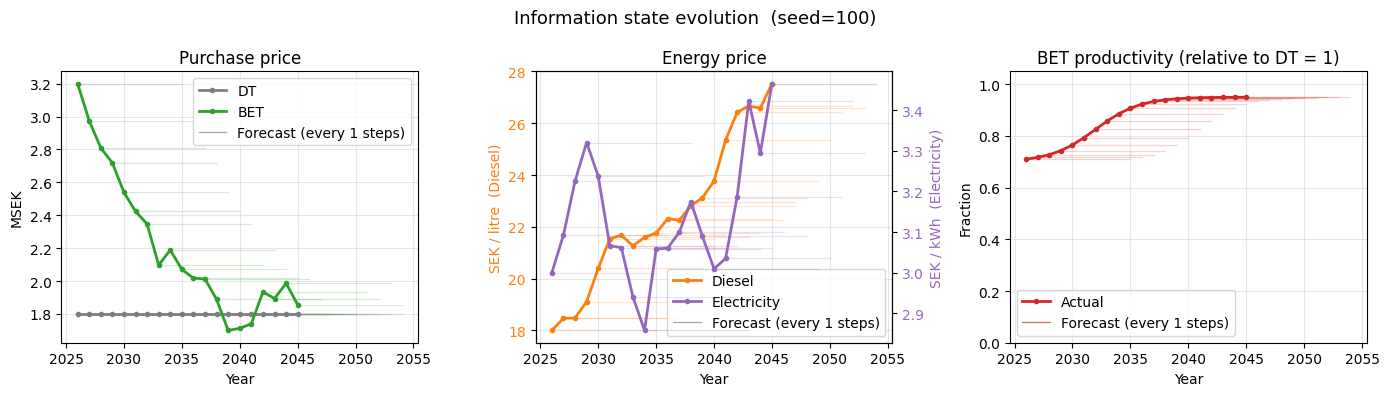

In [5]:
from plot_helpers import plot_episode_information_state

plot_episode_information_state(record, agent)

In [6]:
record.reward_component("sale_result")

array([ 936000.        ,  936000.        ,  936000.        ,
        936000.        ,  936000.        ,  936000.        ,
        936000.        ,  936000.        ,  936000.        ,
        936000.        , 3024000.        ,       0.        ,
             0.        ,  949005.24439112,  948293.64570917,
        939416.23421975, 1030772.35541228, 1002518.38957882,
       3107759.4613878 ,       0.        ])